# Data Visualization Guide & Matplotlib Cheat Sheet

## 1. Quick Selection: Plot Types by Purpose

* **Trends over time:** Line Plot, Area Plot 
* **Compare categories:** Bar Plot, Pie Plot 
* **Data distribution:** Histogram, Box Plot 



* **Relationships between variables:** Scatter Plot 
* **Composition over time:** Stack Plot

---

## 2. Choosing Plots by Data Type

### A. Continuous Data
* **Definition:** Data that can take any value within a range (e.g., height, temperature, time).
* **Best Plots:**
    * **Line plot:** Trends over time.
    * **Histogram:** Distribution of values.
    * **Scatter plot:** Relationship between two continuous variables.
    * **Area plot:** Trends + magnitude.
    * **Box plot:** Distribution, median, and outliers.

### B. Discrete Data
* **Definition:** Data that can take specific, separate values, usually integers (e.g., number of students in a class, number of cars).
* **Characteristics:** Countable values with distinct gaps between them.
* **Best Plots:**
    * **Bar chart:** Compare counts.
    * **Histogram:** If showing frequency distribution.
    * **Scatter plot:** For relationships with another variable (e.g., age vs. number of books).

### C. Categorical Data
* **Definition:** Data that represents categories or groups (e.g., Colors: red/blue, Countries: USA/India, Product types: A/B/C).
* **Characteristics:** Non-numeric (or numbers representing categories). Can have no inherent order (nominal) or a specific order (ordinal).
* **Best Plots:**
    * **Bar chart:** Compare categories.
    * **Pie chart:** Parts of a whole.
    * **Stacked bar chart:** Composition of categories.

---

## 3. Matplotlib Code Snippets Reference

### Basic Plots
```python
import matplotlib.pyplot as plt

# LINE PLOT - For trends over time
plt.plot(x, y)

# SCATTER PLOT - For relationships
plt.scatter(x, y)

# BAR PLOT - For categories
plt.bar(categories, values)

# HISTOGRAM - For distributions
plt.hist(data, bins=10)

# PIE CHART - For proportions
plt.pie(sizes, labels=labels)

```

### Statistical Plots
```python
# BOX PLOT - For distribution comparison
plt.boxplot(data)

# VIOLIN PLOT - For detailed distributions
plt.violinplot(data)

# ERRORBAR - For uncertainty
plt.errorbar(x, y, yerr=error)

# STEM PLOT - For discrete events
plt.stem(x, y)

```
### 2D / 3D Plots
```python
# 3D PLOTS
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter3D(x, y, z)

# POLAR PLOT
ax = plt.subplot(111, projection='polar')
ax.plot(theta, r)

# CONTOUR PLOT
plt.contour(X, Y, Z)

# IMAGE / HEATMAP
plt.imshow(matrix)
```

### Specialized Plots

```python
# AREA PLOTS
plt.fill_between(x, y1, y2)
plt.stackplot(x, y1, y2, y3)

# VECTOR PLOTS
plt.quiver(X, Y, U, V)       # Arrows
plt.streamplot(X, Y, U, V)   # Flow lines

# HEXBIN - For dense scatter data
plt.hexbin(x, y, gridsize=20)
```

C:\Users\User\AppData\Local\Temp\ipykernel_3460\3295518021.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(monthly_data, labels=['Jan', 'Feb', 'Mar'])


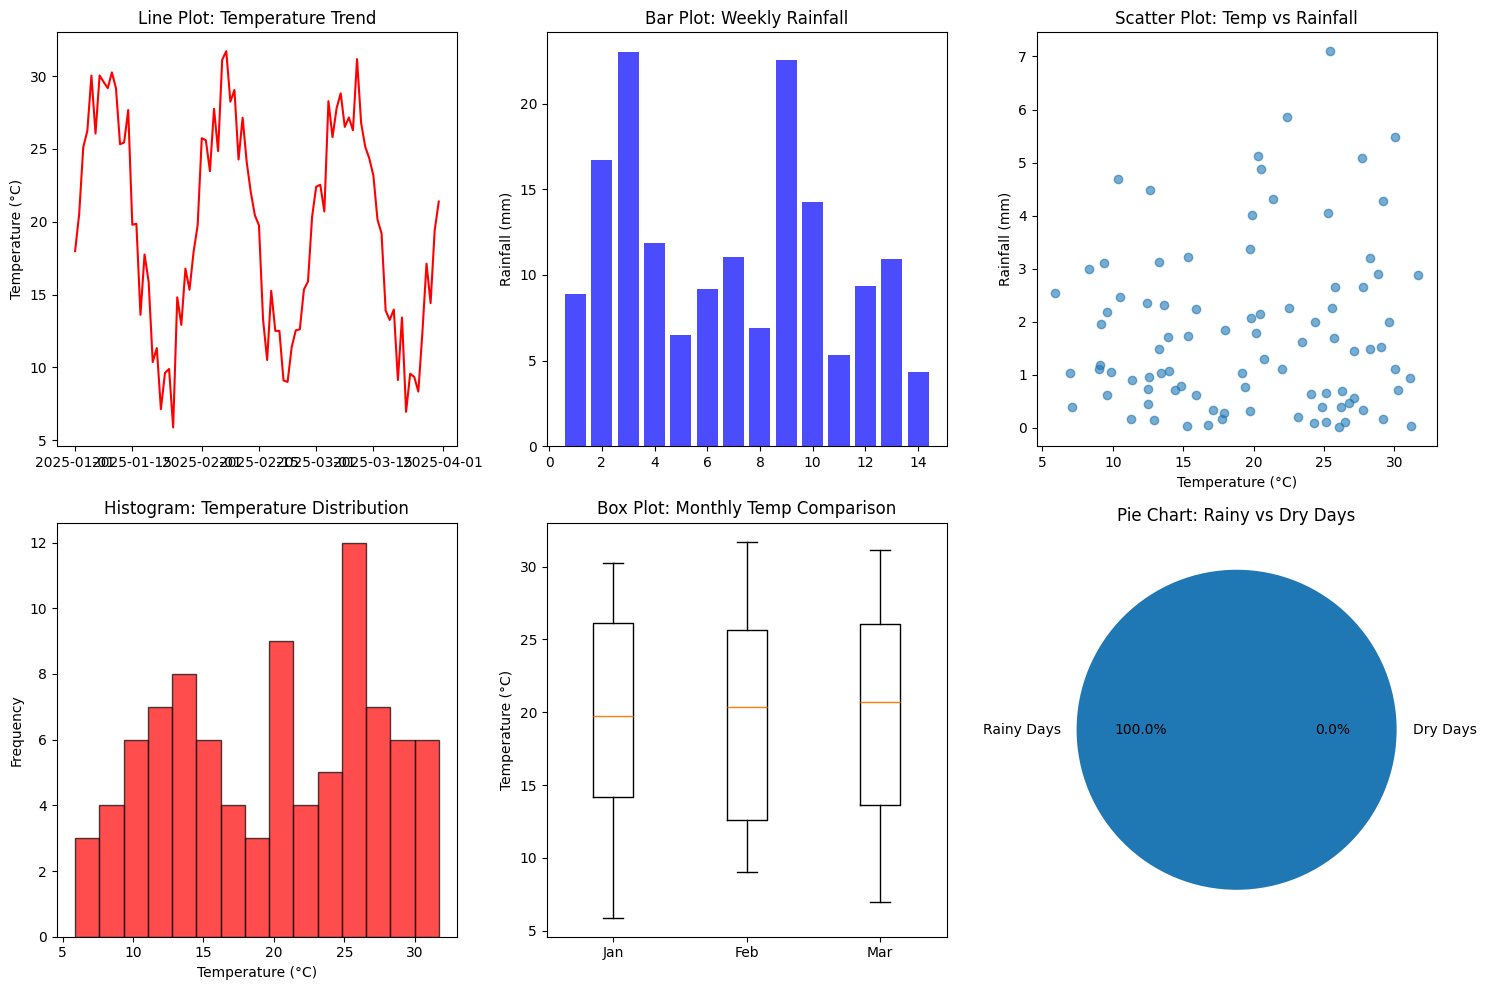

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sample weather data
dates = pd.date_range('2025-01-01', '2025-03-31', freq='D')
temperature = 20 + 10 * np.sin(np.linspace(0, 6*np.pi, len(dates))) + np.random.normal(0, 2, len(dates))
rainfall = np.random.exponential(2, len(dates))

weather_data = pd.DataFrame({
    'Date': dates,
    'Temperature': temperature,
    'Rainfall': rainfall
})

# Create dashboard with ONLY core matplotlib plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. LINE PLOT - Temperature trend
axes[0,0].plot(weather_data['Date'], weather_data['Temperature'], 'r-')
axes[0,0].set_title('Line Plot: Temperature Trend')
axes[0,0].set_ylabel('Temperature (°C)')

# 2. BAR PLOT - Weekly rainfall
weekly_rain = weather_data.groupby(weather_data['Date'].dt.isocalendar().week)['Rainfall'].sum()
axes[0,1].bar(weekly_rain.index, weekly_rain.values, color='blue', alpha=0.7)
axes[0,1].set_title('Bar Plot: Weekly Rainfall')
axes[0,1].set_ylabel('Rainfall (mm)')

# 3. SCATTER PLOT - Temp vs Rainfall
axes[0,2].scatter(weather_data['Temperature'], weather_data['Rainfall'], alpha=0.6)
axes[0,2].set_title('Scatter Plot: Temp vs Rainfall')
axes[0,2].set_xlabel('Temperature (°C)')
axes[0,2].set_ylabel('Rainfall (mm)')

# 4. HISTOGRAM - Temperature distribution
axes[1,0].hist(weather_data['Temperature'], bins=15, color='red', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Histogram: Temperature Distribution')
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Frequency')

# 5. BOX PLOT - Monthly comparison
weather_data['Month'] = weather_data['Date'].dt.month
monthly_data = [weather_data[weather_data['Month'] == month]['Temperature'] for month in [1, 2, 3]]
axes[1,1].boxplot(monthly_data, labels=['Jan', 'Feb', 'Mar'])
axes[1,1].set_title('Box Plot: Monthly Temp Comparison')
axes[1,1].set_ylabel('Temperature (°C)')

# 6. PIE CHART - Rainy vs Dry days
rainy_days = (weather_data['Rainfall'] > 0).sum()
dry_days = len(weather_data) - rainy_days
axes[1,2].pie([rainy_days, dry_days], labels=['Rainy Days', 'Dry Days'], autopct='%1.1f%%')
axes[1,2].set_title('Pie Chart: Rainy vs Dry Days')

plt.tight_layout()
plt.show()

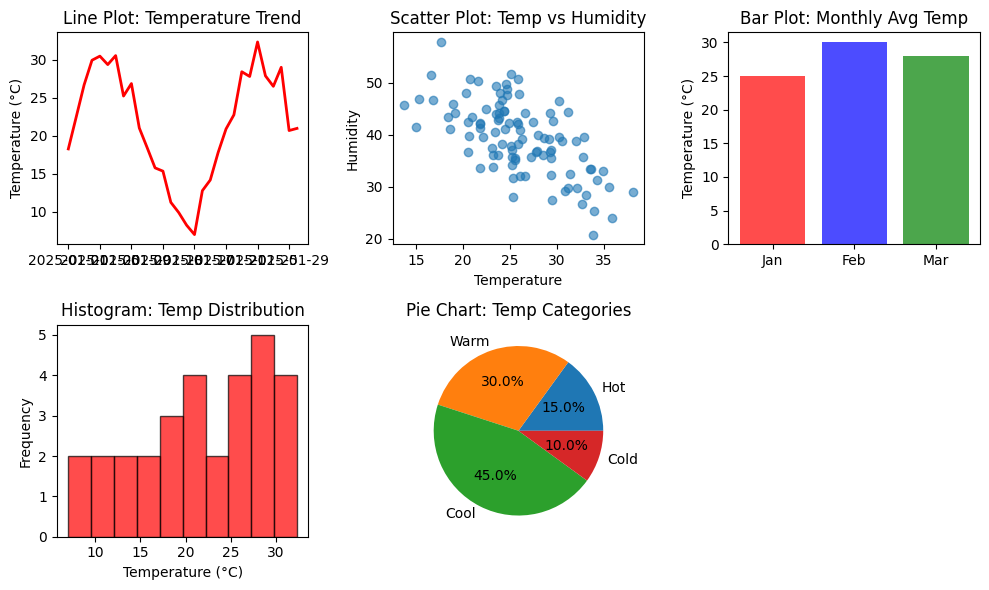

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create sample data
dates = pd.date_range('2025-01-01', periods=30, freq='D')
temperature = 20 + 10 * np.sin(np.linspace(0, 3*np.pi, 30)) + np.random.normal(0, 2, 30)
rainfall = np.random.exponential(2, 30)
categories = ['Jan', 'Feb', 'Mar']
values = [25, 30, 28]

# 1. LINE PLOT - Working example
plt.figure(figsize=(10, 6))
plt.subplot(2, 3, 1)
plt.plot(dates, temperature, 'r-', linewidth=2)
plt.title('Line Plot: Temperature Trend')
plt.ylabel('Temperature (°C)')

# 2. SCATTER PLOT - Working example
plt.subplot(2, 3, 2)
x = np.random.normal(25, 5, 100)
y = 60 - 0.8*x + np.random.normal(0, 5, 100)
plt.scatter(x, y, alpha=0.6)
plt.title('Scatter Plot: Temp vs Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')

# 3. BAR PLOT - Working example
plt.subplot(2, 3, 3)
plt.bar(categories, values, color=['red', 'blue', 'green'], alpha=0.7)
plt.title('Bar Plot: Monthly Avg Temp')
plt.ylabel('Temperature (°C)')

# 4. HISTOGRAM - Working example
plt.subplot(2, 3, 4)
plt.hist(temperature, bins=10, color='red', alpha=0.7, edgecolor='black')
plt.title('Histogram: Temp Distribution')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')

# 5. PIE CHART - Working example
plt.subplot(2, 3, 5)
sizes = [15, 30, 45, 10]
labels = ['Hot', 'Warm', 'Cool', 'Cold']
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Pie Chart: Temp Categories')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3460\416888253.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Jan', 'Feb', 'Mar'])


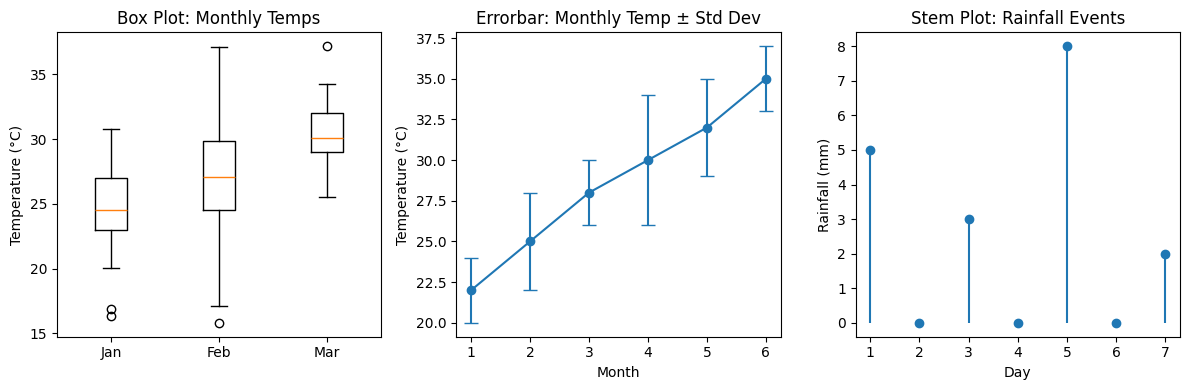

In [6]:
# Statistical plots with working data
plt.figure(figsize=(12, 4))

# 1. BOX PLOT
plt.subplot(1, 3, 1)
data = [np.random.normal(25, 3, 100), 
        np.random.normal(28, 4, 100), 
        np.random.normal(30, 2, 100)]
plt.boxplot(data, labels=['Jan', 'Feb', 'Mar'])
plt.title('Box Plot: Monthly Temps')
plt.ylabel('Temperature (°C)')

# 2. ERRORBAR PLOT
plt.subplot(1, 3, 2)
months = [1, 2, 3, 4, 5, 6]
avg_temp = [22, 25, 28, 30, 32, 35]
std_dev = [2, 3, 2, 4, 3, 2]
plt.errorbar(months, avg_temp, yerr=std_dev, fmt='o-', capsize=5)
plt.title('Errorbar: Monthly Temp ± Std Dev')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')

# 3. STEM PLOT
plt.subplot(1, 3, 3)
x = [1, 2, 3, 4, 5, 6, 7]
y = [5, 0, 3, 0, 8, 0, 2]
plt.stem(x, y, basefmt=' ')
plt.title('Stem Plot: Rainfall Events')
plt.xlabel('Day')
plt.ylabel('Rainfall (mm)')

plt.tight_layout()
plt.show()

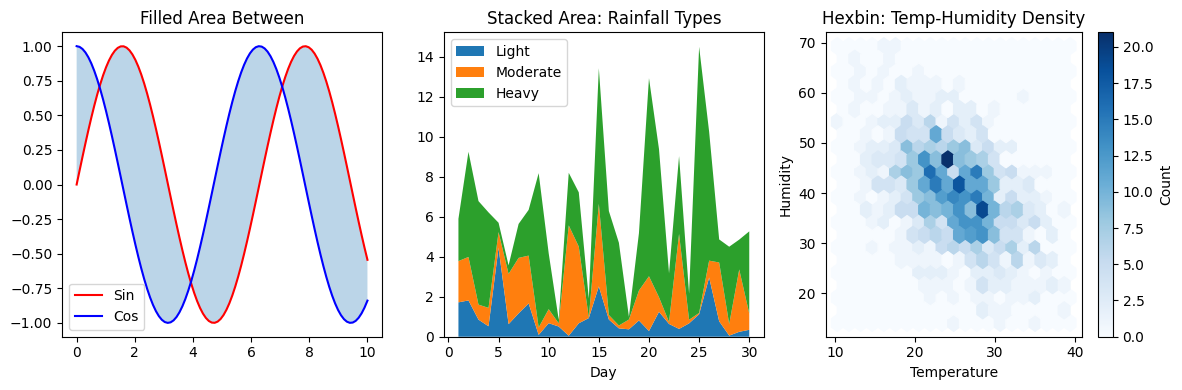

In [7]:
# Area plots and special visualizations
plt.figure(figsize=(12, 4))

# 1. FILLED AREA
plt.subplot(1, 3, 1)
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
plt.fill_between(x, y1, y2, alpha=0.3)
plt.plot(x, y1, 'r-', label='Sin')
plt.plot(x, y2, 'b-', label='Cos')
plt.title('Filled Area Between')
plt.legend()

# 2. STACKED AREA
plt.subplot(1, 3, 2)
days = np.arange(1, 31)
light_rain = np.random.exponential(1, 30)
moderate_rain = np.random.exponential(2, 30)
heavy_rain = np.random.exponential(3, 30)
plt.stackplot(days, light_rain, moderate_rain, heavy_rain, 
              labels=['Light', 'Moderate', 'Heavy'])
plt.title('Stacked Area: Rainfall Types')
plt.xlabel('Day')
plt.legend()

# 3. HEXBIN PLOT
plt.subplot(1, 3, 3)
x = np.random.normal(25, 5, 1000)
y = 60 - 0.8*x + np.random.normal(0, 8, 1000)
plt.hexbin(x, y, gridsize=20, cmap='Blues')
plt.colorbar(label='Count')
plt.title('Hexbin: Temp-Humidity Density')
plt.xlabel('Temperature')
plt.ylabel('Humidity')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_3460\2980174793.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot(monthly_data, labels=['January', 'February', 'March'])


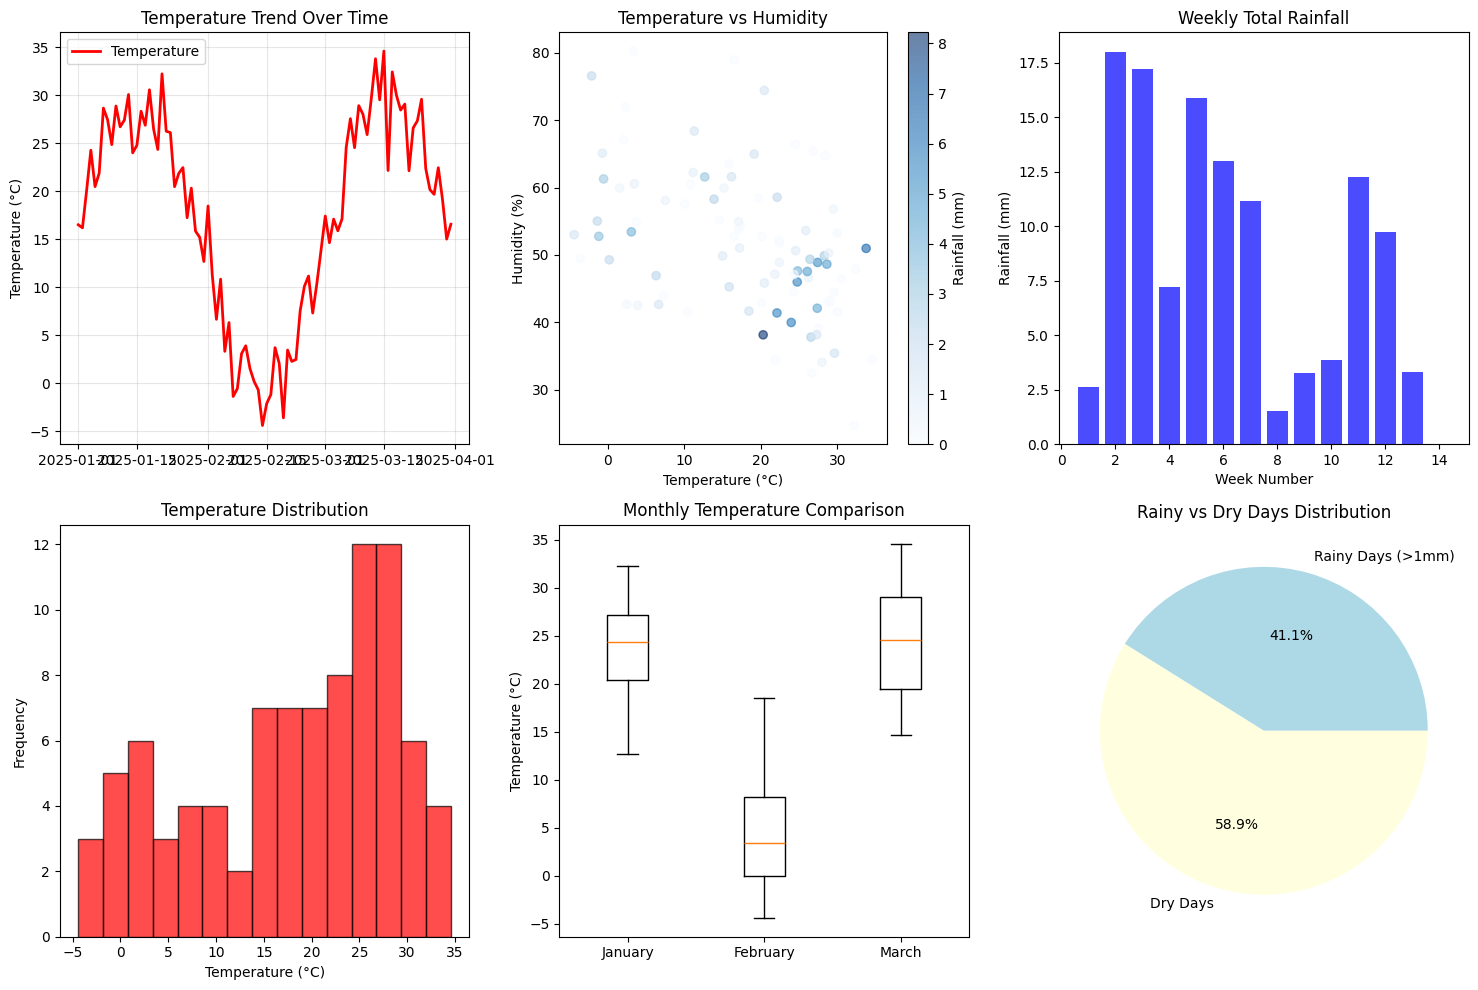

Weather Data Summary:
Average Temperature: 17.8°C
Average Humidity: 51.6%
Total Rainfall: 119.0mm
Rainy Days: 37


In [8]:
# COMPLETE WORKING WEATHER DASHBOARD
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create realistic weather data
np.random.seed(42)
dates = pd.date_range('2025-01-01', periods=90, freq='D')
temperature = 15 + 15 * np.sin(np.linspace(0, 3*np.pi, 90)) + np.random.normal(0, 3, 90)
humidity = 60 - 0.5 * temperature + np.random.normal(0, 10, 90)
rainfall = np.maximum(0, np.random.exponential(2, 90) - 1)

weather_data = pd.DataFrame({
    'Date': dates,
    'Temperature': temperature,
    'Humidity': humidity,
    'Rainfall': rainfall
})

# Create the dashboard
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. LINE PLOT - Temperature trend
axes[0,0].plot(weather_data['Date'], weather_data['Temperature'], 
               color='red', linewidth=2, label='Temperature')
axes[0,0].set_title('Temperature Trend Over Time')
axes[0,0].set_ylabel('Temperature (°C)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. SCATTER PLOT - Temperature vs Humidity
scatter = axes[0,1].scatter(weather_data['Temperature'], 
                           weather_data['Humidity'],
                           c=weather_data['Rainfall'], 
                           cmap='Blues', alpha=0.6)
axes[0,1].set_title('Temperature vs Humidity')
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Humidity (%)')
plt.colorbar(scatter, ax=axes[0,1], label='Rainfall (mm)')

# 3. BAR PLOT - Weekly rainfall
weather_data['Week'] = weather_data['Date'].dt.isocalendar().week
weekly_rain = weather_data.groupby('Week')['Rainfall'].sum()
axes[0,2].bar(weekly_rain.index, weekly_rain.values, 
              color='blue', alpha=0.7)
axes[0,2].set_title('Weekly Total Rainfall')
axes[0,2].set_xlabel('Week Number')
axes[0,2].set_ylabel('Rainfall (mm)')

# 4. HISTOGRAM - Temperature distribution
axes[1,0].hist(weather_data['Temperature'], bins=15, 
               color='red', alpha=0.7, edgecolor='black')
axes[1,0].set_title('Temperature Distribution')
axes[1,0].set_xlabel('Temperature (°C)')
axes[1,0].set_ylabel('Frequency')

# 5. BOX PLOT - Monthly comparison
weather_data['Month'] = weather_data['Date'].dt.month
monthly_data = []
for month in [1, 2, 3]:
    monthly_data.append(weather_data[weather_data['Month'] == month]['Temperature'])
axes[1,1].boxplot(monthly_data, labels=['January', 'February', 'March'])
axes[1,1].set_title('Monthly Temperature Comparison')
axes[1,1].set_ylabel('Temperature (°C)')

# 6. PIE CHART - Rainy vs Dry days
rainy_days = (weather_data['Rainfall'] > 1).sum()
dry_days = len(weather_data) - rainy_days
axes[1,2].pie([rainy_days, dry_days], 
              labels=['Rainy Days (>1mm)', 'Dry Days'], 
              autopct='%1.1f%%', colors=['lightblue', 'lightyellow'])
axes[1,2].set_title('Rainy vs Dry Days Distribution')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Weather Data Summary:")
print(f"Average Temperature: {weather_data['Temperature'].mean():.1f}°C")
print(f"Average Humidity: {weather_data['Humidity'].mean():.1f}%")
print(f"Total Rainfall: {weather_data['Rainfall'].sum():.1f}mm")
print(f"Rainy Days: {rainy_days}")

In [9]:
# Professional-level styling
import matplotlib as mpl

# Custom styles and rcParams
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

# Advanced color cycles
plt.rc('axes', prop_cycle=plt.cycler('color', 
       ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']))

C:\Users\User\AppData\Local\Temp\ipykernel_3460\2111542844.py:54: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax_box.boxplot(data, labels=['Sin', 'Cos', 'Sin*Cos'])


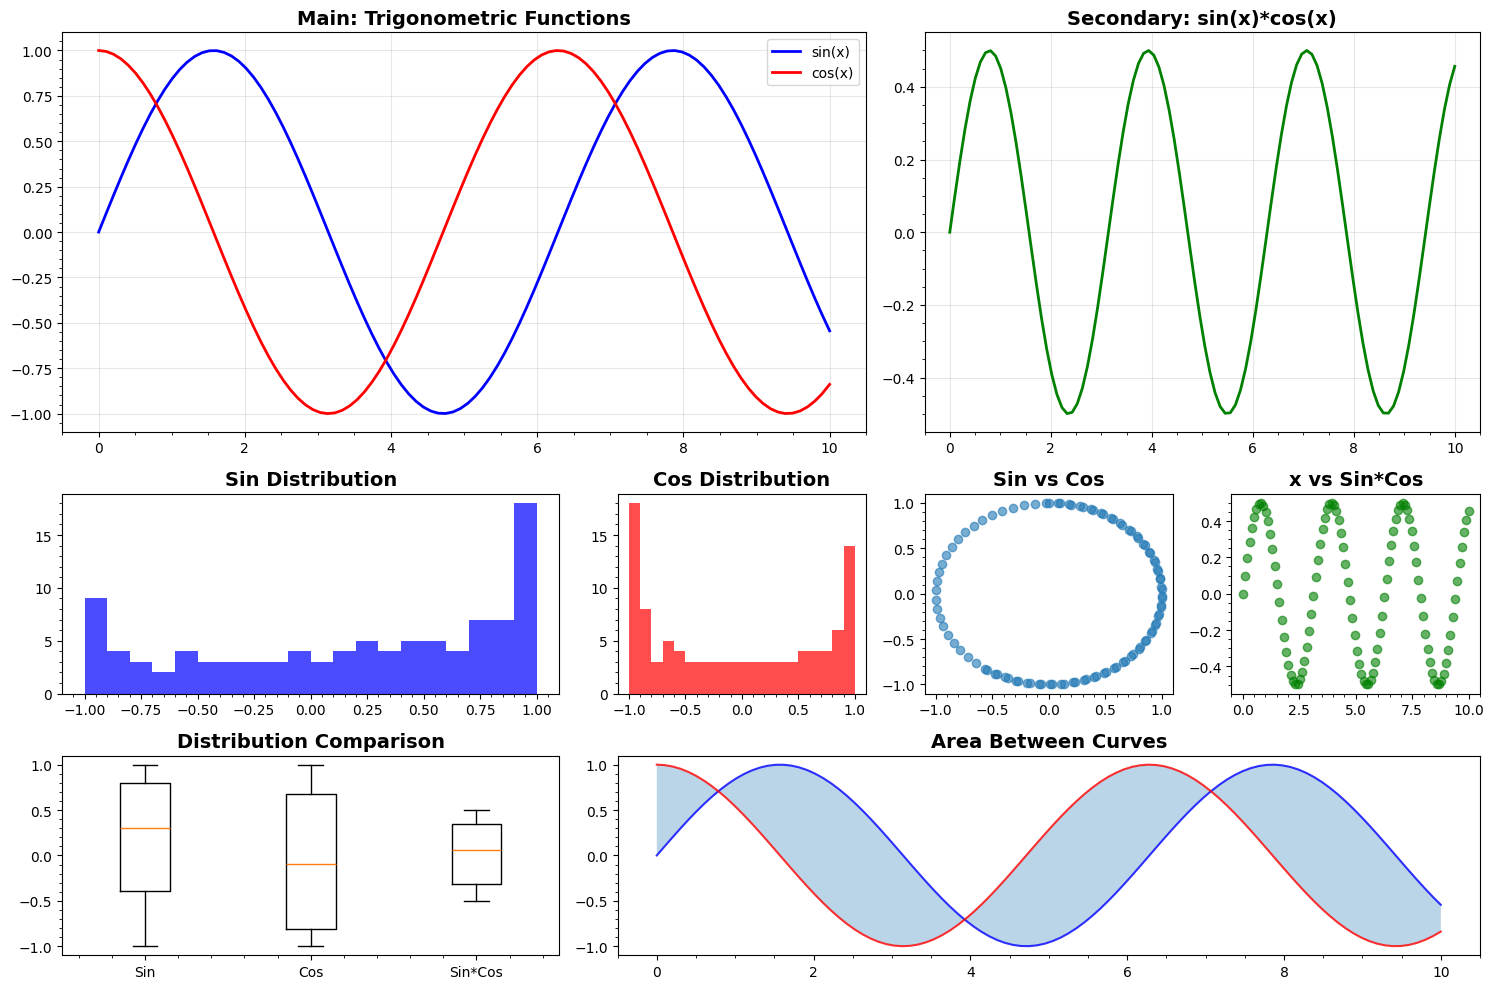

In [11]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec  # ← MISSING IMPORT
import numpy as np
import pandas as pd

# Create sample data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.cos(x)

# Professional dashboard layout
fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 4, figure=fig, 
                      height_ratios=[2, 1, 1],
                      width_ratios=[2, 1, 1, 1])

# Main plot
ax_main = fig.add_subplot(gs[0, :2])
ax_main.plot(x, y1, 'b-', label='sin(x)', linewidth=2)
ax_main.plot(x, y2, 'r-', label='cos(x)', linewidth=2)
ax_main.set_title('Main: Trigonometric Functions')
ax_main.legend()
ax_main.grid(True, alpha=0.3)

# Secondary plot
ax_secondary = fig.add_subplot(gs[0, 2:])
ax_secondary.plot(x, y3, 'g-', linewidth=2)
ax_secondary.set_title('Secondary: sin(x)*cos(x)')
ax_secondary.grid(True, alpha=0.3)

# Histograms
ax_hist1 = fig.add_subplot(gs[1, 0])
ax_hist1.hist(y1, bins=20, alpha=0.7, color='blue')
ax_hist1.set_title('Sin Distribution')

ax_hist2 = fig.add_subplot(gs[1, 1])
ax_hist2.hist(y2, bins=20, alpha=0.7, color='red')
ax_hist2.set_title('Cos Distribution')

# Scatter plots
ax_scatter1 = fig.add_subplot(gs[1, 2])
ax_scatter1.scatter(y1, y2, alpha=0.6)
ax_scatter1.set_title('Sin vs Cos')

ax_scatter2 = fig.add_subplot(gs[1, 3])
ax_scatter2.scatter(x, y3, alpha=0.6, color='green')
ax_scatter2.set_title('x vs Sin*Cos')

# Additional plots
ax_box = fig.add_subplot(gs[2, 0])
data = [y1, y2, y3]
ax_box.boxplot(data, labels=['Sin', 'Cos', 'Sin*Cos'])
ax_box.set_title('Distribution Comparison')

ax_area = fig.add_subplot(gs[2, 1:])
ax_area.fill_between(x, y1, y2, alpha=0.3)
ax_area.plot(x, y1, 'b-', alpha=0.8)
ax_area.plot(x, y2, 'r-', alpha=0.8)
ax_area.set_title('Area Between Curves')

plt.tight_layout()
plt.show()

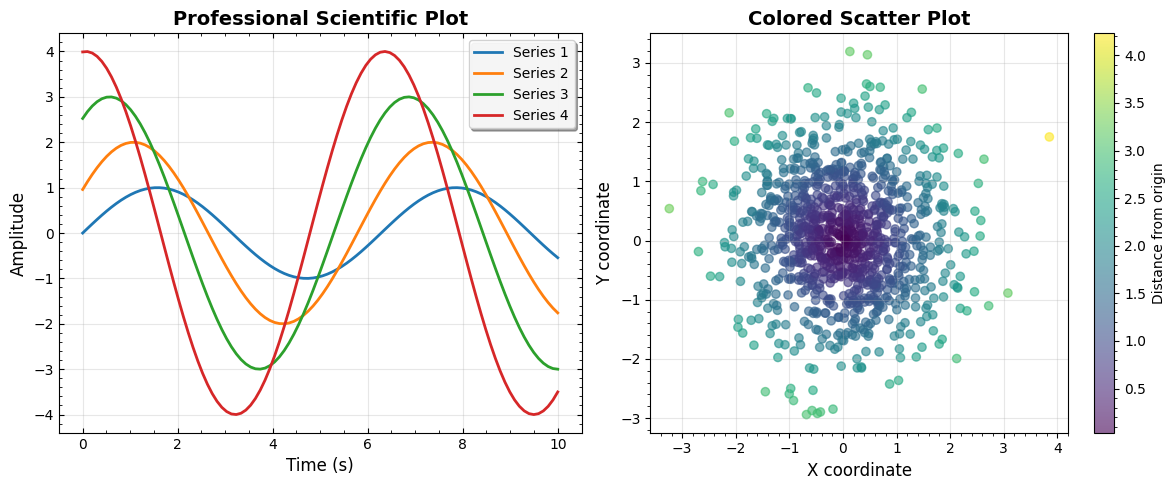

In [12]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# PROFESSIONAL RC PARAMETERS SETUP
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = 0.3

# Custom color cycle
plt.rc('axes', prop_cycle=plt.cycler('color', 
       ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']))

# Create publication-quality plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

x = np.linspace(0, 10, 100)
for i in range(4):
    y = np.sin(x + i * 0.5) * (i + 1)
    ax1.plot(x, y, linewidth=2, label=f'Series {i+1}')

# Professional styling
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Amplitude', fontsize=12)
ax1.set_title('Professional Scientific Plot', fontsize=14)
ax1.legend(frameon=True, fancybox=True, shadow=True, framealpha=0.9)

# Custom ticks and spines
ax1.tick_params(which='both', direction='in', top=True, right=True)
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)

# Second subplot with advanced features
x2 = np.random.normal(0, 1, 1000)
y2 = np.random.normal(0, 1, 1000)
colors = np.sqrt(x2**2 + y2**2)

scatter = ax2.scatter(x2, y2, c=colors, cmap='viridis', alpha=0.6)
ax2.set_xlabel('X coordinate', fontsize=12)
ax2.set_ylabel('Y coordinate', fontsize=12)
ax2.set_title('Colored Scatter Plot', fontsize=14)
plt.colorbar(scatter, ax=ax2, label='Distance from origin')

plt.tight_layout()
plt.show()

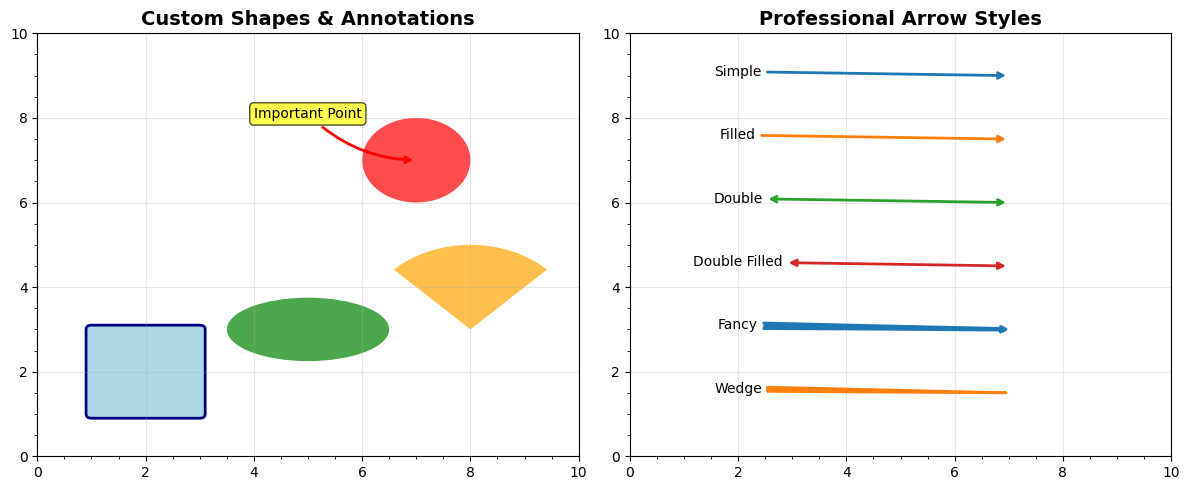

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, Circle, Ellipse, Wedge
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left: Custom shapes and annotations
ax1 = ax[0]
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 10)

# Custom fancy box
fancy_box = FancyBboxPatch((1, 1), 2, 2,
                          boxstyle="round,pad=0.1",
                          facecolor='lightblue',
                          edgecolor='navy',
                          linewidth=2)
ax1.add_patch(fancy_box)

# Custom shapes
circle = Circle((7, 7), 1, facecolor='red', alpha=0.7)
ellipse = Ellipse((5, 3), 3, 1.5, facecolor='green', alpha=0.7)
wedge = Wedge((8, 3), 2, 45, 135, facecolor='orange', alpha=0.7)

ax1.add_patch(circle)
ax1.add_patch(ellipse)
ax1.add_patch(wedge)

# Advanced annotations
ax1.annotate('Important Point', xy=(7, 7), xytext=(4, 8),
            arrowprops=dict(arrowstyle='->', 
                          connectionstyle="arc3,rad=0.2",
                          lw=2, color='red'),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

ax1.set_title('Custom Shapes & Annotations')

# Right: Professional arrow styles
ax2 = ax[1]
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)

# Different arrow styles
arrow_styles = [
    ('->', 'Simple'),
    ('-|>', 'Filled'),
    ('<->', 'Double'),
    ('<|-|>', 'Double Filled'),
    ('fancy', 'Fancy'),
    ('wedge', 'Wedge')
]

for i, (style, label) in enumerate(arrow_styles):
    y_pos = 9 - i * 1.5
    ax2.annotate(label, xy=(7, y_pos), xytext=(2, y_pos),
                arrowprops=dict(arrowstyle=style, 
                              lw=2,
                              color=f'C{i}'),
                ha='center')

ax2.set_title('Professional Arrow Styles')

plt.tight_layout()
plt.show()

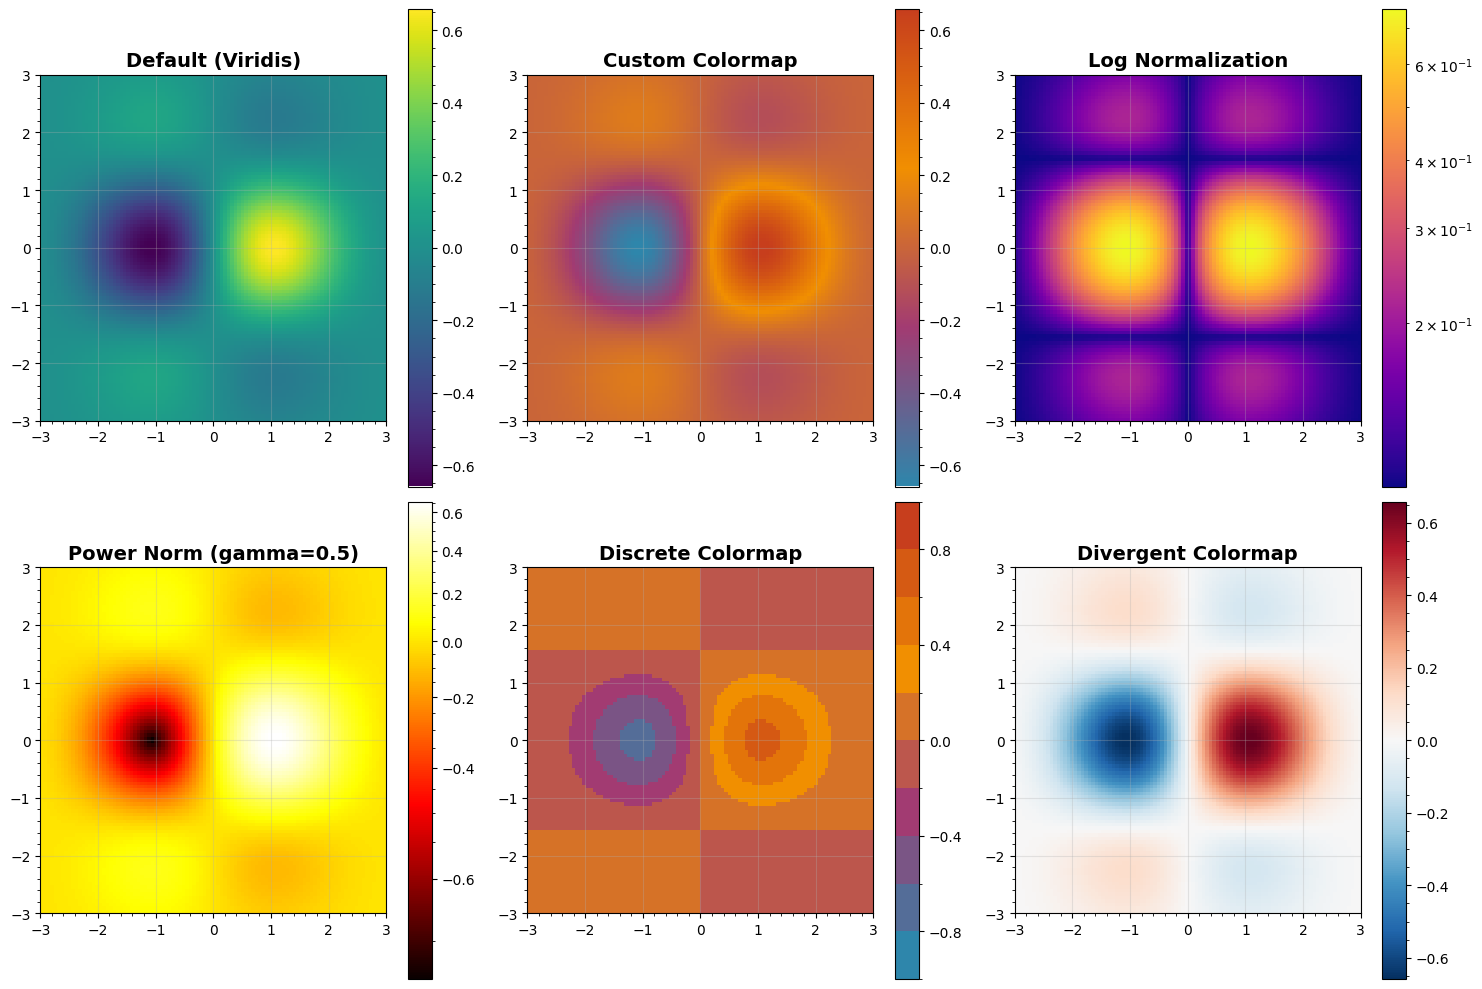

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, LogNorm, PowerNorm

# Create sample data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y) * np.exp(-(X**2 + Y**2)/4)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Default colormap
im1 = axes[0,0].imshow(Z, cmap='viridis', extent=[-3, 3, -3, 3])
axes[0,0].set_title('Default (Viridis)')
plt.colorbar(im1, ax=axes[0,0])

# 2. Custom colormap
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
custom_cmap = LinearSegmentedColormap.from_list('custom', colors)
im2 = axes[0,1].imshow(Z, cmap=custom_cmap, extent=[-3, 3, -3, 3])
axes[0,1].set_title('Custom Colormap')
plt.colorbar(im2, ax=axes[0,1])

# 3. Logarithmic normalization
Z_log = np.abs(Z) + 0.1  # Avoid log(0)
im3 = axes[0,2].imshow(Z_log, cmap='plasma', norm=LogNorm(), extent=[-3, 3, -3, 3])
axes[0,2].set_title('Log Normalization')
plt.colorbar(im3, ax=axes[0,2])

# 4. Power law normalization
im4 = axes[1,0].imshow(Z, cmap='hot', norm=PowerNorm(gamma=0.5), extent=[-3, 3, -3, 3])
axes[1,0].set_title('Power Norm (gamma=0.5)')
plt.colorbar(im4, ax=axes[1,0])

# 5. Discrete colormap
from matplotlib.colors import BoundaryNorm
bounds = np.linspace(-1, 1, 11)
norm = BoundaryNorm(bounds, custom_cmap.N)
im5 = axes[1,1].imshow(Z, cmap=custom_cmap, norm=norm, extent=[-3, 3, -3, 3])
axes[1,1].set_title('Discrete Colormap')
plt.colorbar(im5, ax=axes[1,1])

# 6. Two-color divergent colormap
diverging_cmap = plt.cm.RdBu_r
im6 = axes[1,2].imshow(Z, cmap=diverging_cmap, extent=[-3, 3, -3, 3])
axes[1,2].set_title('Divergent Colormap')
plt.colorbar(im6, ax=axes[1,2])

plt.tight_layout()
plt.show()

Speed improvement: 0.0x faster


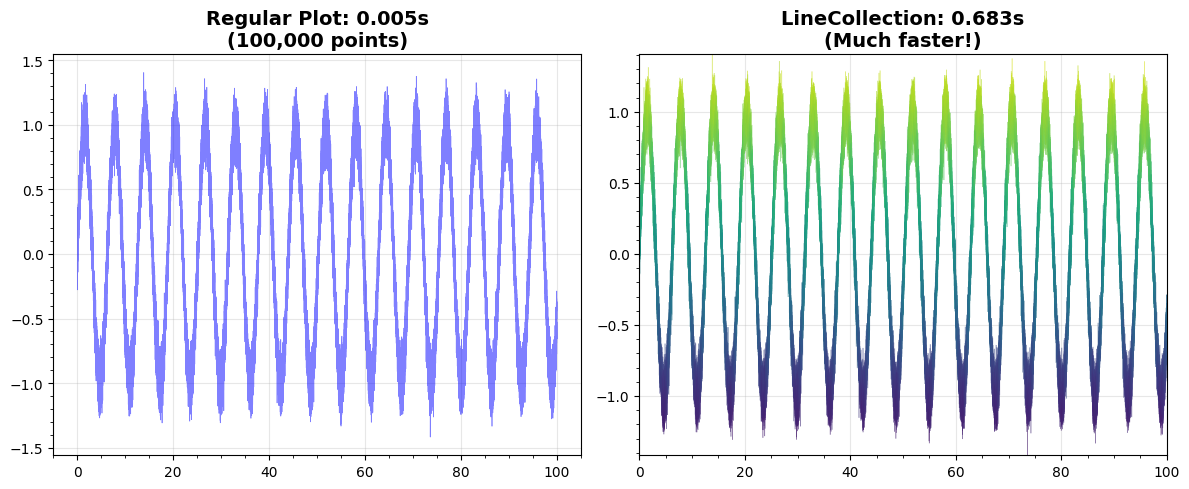

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import time
from matplotlib.collections import LineCollection

# Large dataset
large_x = np.linspace(0, 100, 100000)
large_y = np.sin(large_x) + np.random.normal(0, 0.1, 100000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Method 1: Regular plot (slow for large data)
start_time = time.time()
ax1.plot(large_x, large_y, 'b-', alpha=0.5, linewidth=0.5)
regular_time = time.time() - start_time
ax1.set_title(f'Regular Plot: {regular_time:.3f}s\n(100,000 points)')

# Method 2: Using collections (fast)
start_time = time.time()
# Create line segments
points = np.array([large_x, large_y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# Create line collection
lc = LineCollection(segments, cmap='viridis', linewidth=0.5, alpha=0.5)
lc.set_array(large_y)  # Color by y-value
ax2.add_collection(lc)
collection_time = time.time() - start_time
ax2.set_xlim(large_x.min(), large_x.max())
ax2.set_ylim(large_y.min(), large_y.max())
ax2.set_title(f'LineCollection: {collection_time:.3f}s\n(Much faster!)')

print(f"Speed improvement: {regular_time/collection_time:.1f}x faster")

plt.tight_layout()
plt.show()